In [ ]:
import torch
import torch.nn as nn

# Basic convolution block
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# U-Net model
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder (Down)
        self.down1 = DoubleConv(1, 64)
        self.down2 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.middle = DoubleConv(128, 256)

        # Decoder (Up)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        # Output layer
        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        # Encoder
        c1 = self.down1(x)
        p1 = self.pool(c1)

        c2 = self.down2(p1)
        p2 = self.pool(c2)

        # Middle
        m = self.middle(p2)

        # Decoder
        u2 = self.up2(m)
        u2 = torch.cat([u2, c2], dim=1)
        c3 = self.conv2(u2)

        u1 = self.up1(c3)
        u1 = torch.cat([u1, c1], dim=1)
        c4 = self.conv1(u1)

        return self.out(c4)

# Test the model
if __name__ == "__main__":
    model = UNet()
    x = torch.randn(1, 1, 256, 256)  # batch, channel, height, width
    y = model(x)
    print(y.shape)


torch.Size([1, 1, 256, 256])


In [ ]:
!nvidia-smi

Thu Feb  5 13:13:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
Tesla T4


In [ ]:
!pip install opencv-python torchvision


In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1, 64)
        self.down2 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.middle = DoubleConv(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool(c1)

        c2 = self.down2(p1)
        p2 = self.pool(c2)

        m = self.middle(p2)

        u2 = self.up2(m)
        u2 = torch.cat([u2, c2], dim=1)
        c3 = self.conv2(u2)

        u1 = self.up1(c3)
        u1 = torch.cat([u1, c1], dim=1)
        c4 = self.conv1(u1)

        return self.out(c4)



In [5]:
from google.colab import files

uploaded = files.upload()


Saving testube.jpg to testube (1).jpg


In [11]:
from google.colab import files

uploaded = files.upload()

Saving testube2.png to testube2.png


Processing image: testube.jpg
Plasma height (pixels): 355


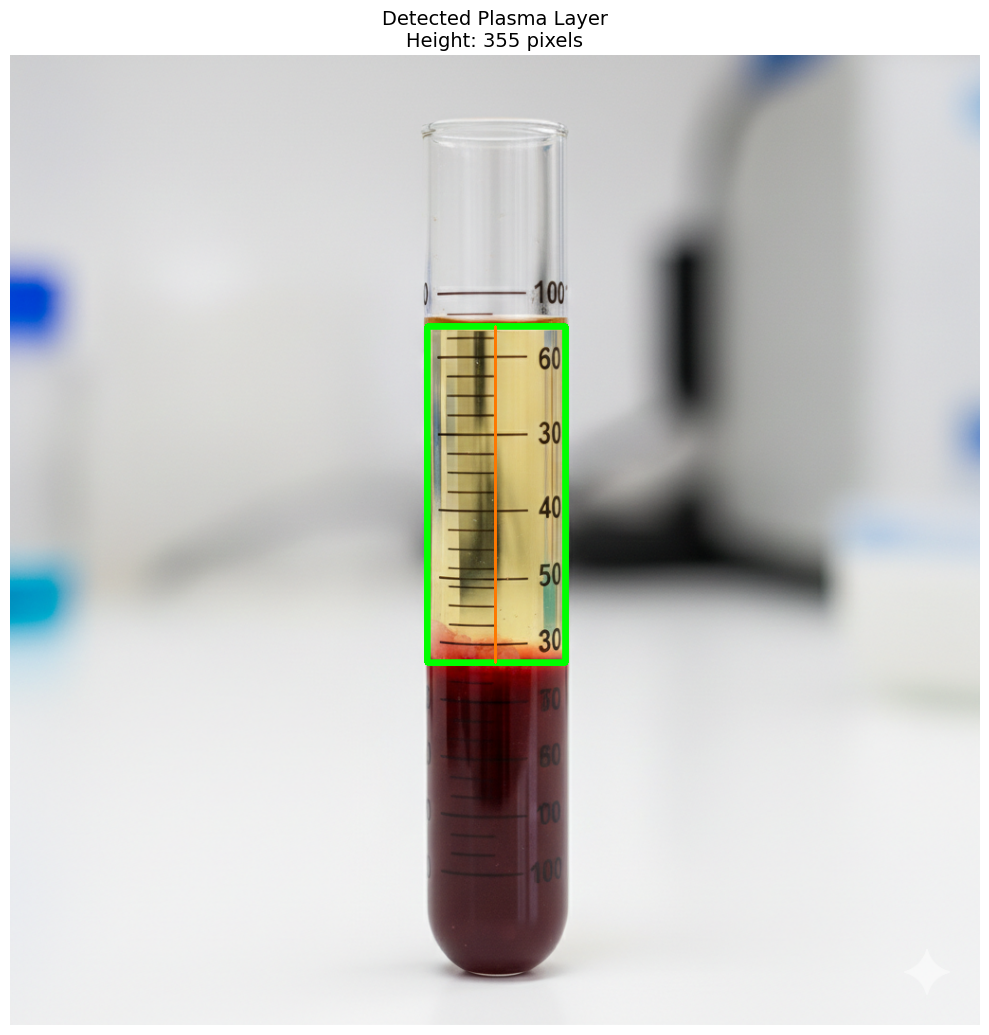

Final result → Plasma height = 355 pixels


In [21]:
# Full standalone script to measure plasma height in a centrifuge tube image
# (improved version with tighter, more accurate horizontal bounding box)

import cv2
import numpy as np
import matplotlib.pyplot as plt

def measure_plasma_height(image_path):
    """
    Detects the plasma layer in a centrifuge tube image and draws a tight bounding box.
    Returns the plasma height in pixels.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image at {image_path}")
        return 0

    orig = img.copy()
    h, w = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # ─── Wide center strip to avoid tube wall reflections ───
    center_x = w // 2
    strip_width = 120                # adjust if your tube is much wider/narrower
    left = max(0, center_x - strip_width // 2)
    right = min(w, center_x + strip_width // 2)
    strip = hsv[:, left:right, :]

    val = np.median(strip[:, :, 2], axis=1)   # median value (brightness)
    sat = np.median(strip[:, :, 1], axis=1)   # median saturation

    # === Find UPPER EDGE: start of clear yellow plasma (meniscus) ===
    plasma_top = None
    streak = 0
    for y in range(150, h - 100):
        if sat[y] > 75 and val[y] > 175:
            streak += 1
            if streak >= 12:
                plasma_top = y - 10           # backtrack slightly for meniscus curve
                break
        else:
            streak = 0

    if plasma_top is None:
        print("Could not detect plasma top (yellow region)")
        plasma_top = 200  # fallback — adjust if needed

    # === Find LOWER EDGE: transition to packed dark-red blood cells ===
    plasma_bottom = None
    for y in range(plasma_top + 80, h - 40):
        if val[y] < 170 and np.mean(val[y:y+25]) < 155:
            plasma_bottom = y
            break

    if plasma_bottom is None:
        print("Could not detect dark red cell bottom")
        plasma_bottom = h - 50  # fallback

    height_px = plasma_bottom - plasma_top
    print(f"Plasma height (pixels): {height_px}")

    # ─── Find REAL left/right bounds of plasma (tight box) ───
    plasma_hsv = hsv[plasma_top:plasma_bottom, :, :]

    # Yellow/orange plasma mask (HSV ranges tuned for plasma)
    yellow_mask = (
        (plasma_hsv[:, :, 0] > 12)  & (plasma_hsv[:, :, 0] < 45) &
        (plasma_hsv[:, :, 1] > 55)  &
        (plasma_hsv[:, :, 2] > 155)
    ).astype(np.uint8) * 255

    # Percentage of plasma-like pixels per column
    col_sums = np.sum(yellow_mask, axis=0).astype(float)
    col_sums /= (plasma_bottom - plasma_top)   # → fraction [0–1]

    # Columns that have significant plasma content
    valid_columns = col_sums > 0.38

    if np.sum(valid_columns) > 20:  # at least some reasonable width
        cols_with_plasma = np.where(valid_columns)[0]
        # Slightly inset to avoid edge noise / partial pixels
        box_left = cols_with_plasma[0] + 3
        box_right = cols_with_plasma[-1] - 2

        # Enforce minimum reasonable width
        if box_right - box_left < 40:
            box_left = center_x - 60
            box_right = center_x + 60
    else:
        print("Warning: no clear plasma columns found — using center fallback")
        box_left = center_x - 80
        box_right = center_x + 80

    # ─── Draw tight bounding box ───
    cv2.rectangle(orig,
                  (box_left, plasma_top),
                  (box_right, plasma_bottom),
                  (0, 255, 0), 5)

    # Optional: center reference line
    cv2.line(orig,
             (center_x, plasma_top),
             (center_x, plasma_bottom),
             (0, 120, 255), 2)

    # ─── Display result ───
    orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 14))
    plt.imshow(orig_rgb)
    plt.axis("off")
    plt.title(f"Detected Plasma Layer\nHeight: {height_px} pixels", fontsize=14)
    plt.tight_layout()
    plt.show()

    return height_px


# ────────────────────────────────────────────────
#                   MAIN EXECUTION
# ────────────────────────────────────────────────

if __name__ == "__main__":
    # Change this to your actual image path
    IMAGE_PATH = "testube.jpg"          # ←←← put your filename here

    print("Processing image:", IMAGE_PATH)
    height = measure_plasma_height(IMAGE_PATH)

    if height > 0:
        print(f"Final result → Plasma height = {height} pixels")
    else:
        print("Detection failed.")